In [1]:
import sys
from pathlib import Path
import subprocess

src_path = str(Path.cwd().parent / "src")
if src_path not in sys.path:
    sys.path.append(src_path)
from ini import initialisation

🎨 Matplotlib Theme 'favorita_dark' erfolgreich geladen.
✅ System bereit (incl. Colors & Deep-Scan)! Alles wurde autonom geladen.
   -> Root: /Users/cristallagus/Desktop/GitHub/Public/retail_demand_analysis/TimeSeries_Guayes_03.09.2025_TEAMWORK
   -> Aliase: os, pd, px, plt, np, sns, ml, sm, go, cfg, Any, pio


environment datei erstellen 

In [2]:
print("Current working directory:", os.getcwd())

PROJECT_ROOT = Path("..").resolve()

# Setze das Arbeitsverzeichnis auf das Hauptprojektverzeichnis
os.chdir(f"{PROJECT_ROOT}")

# Überprüfe, ob das Verzeichnis korrekt gesetzt wurde
print("Current working directory:", os.getcwd())

Current working directory: /Users/cristallagus/Desktop/GitHub/Public/retail_demand_analysis/TimeSeries_Guayes_03.09.2025_TEAMWORK/notebooks
Current working directory: /Users/cristallagus/Desktop/GitHub/Public/retail_demand_analysis/TimeSeries_Guayes_03.09.2025_TEAMWORK


In [3]:
from Favorita_TSA.models.data_preparation import build_dataframes

dfs = build_dataframes()

df_smooth_daily = dfs["smooth_daily"]  # Smooth  aus daily  Matrix
df_erratic_daily = dfs["erratic_daily"]  # Erratic aus daily  Matrix
df_smooth_weekly = dfs["smooth_weekly"]  # Smooth  aus weekly Matrix
df_erratic_weekly = dfs["erratic_weekly"]  # Erratic aus weekly Matrix

Loading fact table …
Loading forecastability matrices …
Building DataFrames …
  smooth_daily         36,560 store-item pairs     39,523,827 rows
  erratic_daily        35,933 store-item pairs     36,705,401 rows
  smooth_weekly        47,196 store-item pairs     30,042,814 rows
  erratic_weekly       19,734 store-item pairs     10,182,367 rows


Smooth Series : Store 25 ; Item_nbr 115611

In [4]:
smooth_test = df_smooth_daily.copy()

In [5]:
smooth_test = smooth_test.drop(
    columns=[
        "id",
        "onpromotion",
        "year",
        "dow",
        "year_iso",
        "week",
        "week_start",
        "month",
    ]
)

In [6]:
smooth_25_115611 = smooth_test.loc[
    (smooth_test["store_nbr"] == 25) & (smooth_test["item_nbr"] == 115611)
]

In [7]:
smooth_25_115611["date"] = pd.to_datetime(smooth_25_115611["date"])

/var/folders/k8/7_ysp8813gz5xdcks_1dkqw40000gn/T/ipykernel_12365/3785735272.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smooth_25_115611["date"] = pd.to_datetime(smooth_25_115611["date"])


In [8]:
range_days = pd.date_range(
    smooth_25_115611["date"].min(), smooth_25_115611["date"].max(), freq="D"
)
df_days = pd.DataFrame(range_days, columns=["date"])

In [9]:
smooth_clean = df_days.merge(smooth_25_115611, on="date", how="left")
smooth_clean.head()

,date,store_nbr,item_nbr,unit_sales
0,2013-01-01,25.0,115611.0,1.0
1,2013-01-02,25.0,115611.0,5.0
2,2013-01-03,25.0,115611.0,5.0
3,2013-01-04,25.0,115611.0,10.0
4,2013-01-05,25.0,115611.0,12.0


In [10]:
fig = px.line(
    smooth_clean,
    x="date",
    y="unit_sales",
    title="Store 25, Item 115611 sales over time",
)
fig.show()

In [11]:
df_holidays_events = parquet_loader(Dataset.HOLIDAYS_EVENTS)

In [12]:
holidays_smooth_clean = df_holidays_events[
    (df_holidays_events["locale_name"].isin(["Santa Elena", "Ecuador"]))
    & (df_holidays_events["type"] != "Work Day")
]

In [13]:
holidays_smooth_clean = holidays_smooth_clean[~holidays_smooth_clean["transferred"]]

In [14]:
holidays_smooth_clean["date"] = pd.to_datetime(holidays_smooth_clean["date"])

In [15]:
smooth_clean["is_holiday_or_event"] = False

In [16]:
holidays_set = set(holidays_smooth_clean["date"])

smooth_clean["is_holiday_or_event"] = smooth_clean["date"].isin(holidays_set)

In [17]:
smooth_clean["date"] = pd.to_datetime(smooth_clean["date"]).dt.normalize()
holidays_smooth_clean["date"] = pd.to_datetime(
    holidays_smooth_clean["date"]
).dt.normalize()

panel_dates = set(smooth_clean["date"].dropna().unique())
holiday_dates = set(holidays_smooth_clean["date"].dropna().unique())

print("Holiday rows:", len(holidays_smooth_clean))
print("Holiday unique dates:", len(holiday_dates))
print(
    "Flagged unique dates in panel:",
    smooth_clean.loc[smooth_clean["is_holiday_or_event"], "date"].nunique(),
)
print("Holiday dates missing in panel:", len(holiday_dates - panel_dates))

Holiday rows: 167
Holiday unique dates: 161
Flagged unique dates in panel: 139
Holiday dates missing in panel: 22


In [18]:
smooth_clean.head()

,date,store_nbr,item_nbr,unit_sales,is_holiday_or_event
0,2013-01-01,25.0,115611.0,1.0,True
1,2013-01-02,25.0,115611.0,5.0,False
2,2013-01-03,25.0,115611.0,5.0,False
3,2013-01-04,25.0,115611.0,10.0,False
4,2013-01-05,25.0,115611.0,12.0,False


In [19]:
ts = (
    smooth_clean.query("store_nbr == 25 & item_nbr == 115611")
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .set_index("date")
    .sort_index()
)

y = ts["unit_sales"]
y = y.asfreq("D")

In [20]:
from statsmodels.tsa.seasonal import STL

stl = STL(y, period=7, robust=True)  # weekly seasonality bei Retail üblich
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residuals = res.resid

In [21]:
print(type(y))
print(y.index.freq)

<class 'pandas.core.series.Series'>
<Day>


In [22]:
from statsmodels.tsa.seasonal import STL

stl = STL(y, period=7, robust=True)  # 7 = Wochen-Saisonalität
res = stl.fit()

ts["trend"] = res.trend
ts["seasonal"] = res.seasonal
ts["resid"] = res.resid

In [23]:
ts = (
    smooth_clean.query("store_nbr == 25 & item_nbr == 115611")
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .sort_values("date")
    .set_index("date")
)

# sicherstellen, dass unit_sales numerisch ist
ts["unit_sales"] = pd.to_numeric(ts["unit_sales"], errors="coerce")

# auf tägliche Frequenz reindizieren (hier entstehen NaNs, wenn Tage fehlen)
ts = ts.asfreq("D")

# fehlende Werte sinnvoll füllen (für Sales oft 0 oder forward-fill - je nach Bedeutung!)
ts["unit_sales"] = ts["unit_sales"].fillna(0)

y = ts["unit_sales"]

In [24]:
ts["unit_sales"] = ts["unit_sales"].interpolate(limit_direction="both")

In [25]:
from statsmodels.tsa.seasonal import STL

stl = STL(y, period=7, robust=True)
res = stl.fit()

ts["trend"] = res.trend
ts["seasonal"] = res.seasonal
ts["resid"] = res.resid

In [26]:
ts.head()

,store_nbr,item_nbr,unit_sales,is_holiday_or_event,trend,seasonal,resid
date,,,,,,,
2013-01-01,25.0,115611.0,1.0,True,4.489248,-3.254296,-0.234951
2013-01-02,25.0,115611.0,5.0,False,5.165546,-0.105409,-0.060137
2013-01-03,25.0,115611.0,5.0,False,5.831396,-0.612391,-0.219005
2013-01-04,25.0,115611.0,10.0,False,6.484886,3.351146,0.163968
2013-01-05,25.0,115611.0,12.0,False,7.124034,4.714883,0.161084


In [27]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# falls noch nicht sortiert
ts = ts.sort_index()

fig = make_subplots(
    rows=4,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    subplot_titles=("unit_sales", "trend", "seasonal", "resid"),
)

fig.add_trace(
    go.Scatter(x=ts.index, y=ts["unit_sales"], mode="lines", name="unit_sales"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=ts.index, y=ts["trend"], mode="lines", name="trend"), row=2, col=1
)
fig.add_trace(
    go.Scatter(x=ts.index, y=ts["seasonal"], mode="lines", name="seasonal"),
    row=3,
    col=1,
)
fig.add_trace(
    go.Scatter(x=ts.index, y=ts["resid"], mode="markers", name="resid"), row=4, col=1
)

fig.update_layout(height=900, showlegend=False)
fig.update_xaxes(title_text="date", row=4, col=1)

fig.show()

In [43]:
holiday = ts[ts["is_holiday_or_event"] == True]  # noqa: E712

fig = go.Figure()

fig.add_trace(
    go.Scatter(x=ts.index, y=ts["unit_sales"], mode="lines", name="unit_sales")
)

fig.add_trace(
    go.Scatter(
        x=holiday.index,
        y=holiday["unit_sales"],
        mode="markers",
        name="holiday/event",
        marker={"size": 5, "symbol": "circle"},
    )
)

fig.update_layout(height=450)
fig.show()

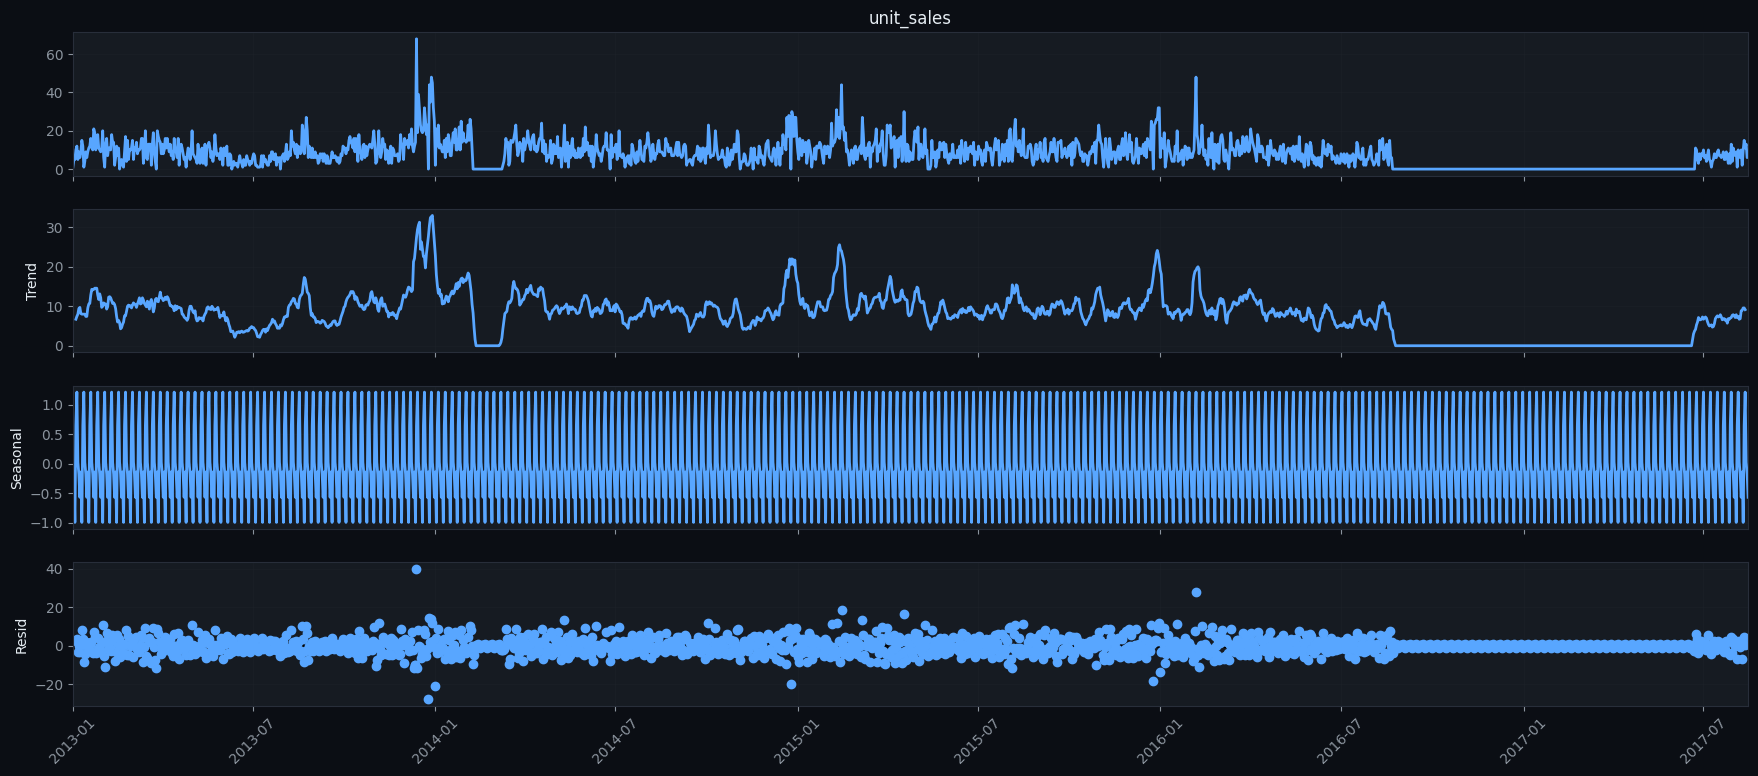

In [29]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1) Series bauen: Index = date, Values = unit_sales
y = (
    smooth_clean.sort_values("date")
    .set_index("date")["unit_sales"]
    .astype(float)
    .asfreq("D")
)  # tägliche Frequenz erzwingen

# Optional: fehlende Tage auffüllen (wenn Lücken existieren)
y = y.fillna(0.0)

# 2) Decomposition (daily -> period=7)
# Multiplicative geht nur ohne Nullen. Da du Nullen haben könntest:
result = seasonal_decompose(y, model="additive", period=7)

# 3) Plot
fig = result.plot()
fig.set_size_inches(20, 8)
plt.xticks(rotation=45)
plt.show()

In [30]:
from Favorita_TSA.utils.fix_and_add_holiday_features import fix_and_add_holiday_features

In [31]:
print(smooth_clean.columns)

Index(['date', 'store_nbr', 'item_nbr', 'unit_sales', 'is_holiday_or_event'], dtype='object')


In [32]:
smooth_clean = fix_and_add_holiday_features(smooth_clean)

🔍 Diagnostiziere DataFrame-Struktur...
   Index type: <class 'pandas.core.indexes.range.RangeIndex'>
   Index dtype: int64
   Index name: None
   Columns: ['date', 'store_nbr', 'item_nbr', 'unit_sales', 'is_holiday_or_event']
✅ Gefunden: 'date' als Spalte

✅ Index repariert:
   Von: 2013-01-01 00:00:00
   Bis: 2017-08-15 00:00:00
   Länge: 1688

🎉 Gefunden: 139 Holidays
   Erste 5: [Timestamp('2013-01-01 00:00:00'), Timestamp('2013-02-11 00:00:00'), Timestamp('2013-02-12 00:00:00'), Timestamp('2013-04-29 00:00:00'), Timestamp('2013-05-01 00:00:00')]

⚙️  Erstelle Pre-Holiday (5 Tage) und Post-Holiday (5 Tage)...

📊 Ergebnis:
   Holidays:     139 Tage (8.2%)
   Pre-Holiday:  367 Tage (21.7%)
   Post-Holiday: 371 Tage (22.0%)
   Regular:      811 Tage (48.0%)


In [33]:
print(smooth_clean.columns)

Index(['store_nbr', 'item_nbr', 'unit_sales', 'is_holiday_or_event',
       'pre_holiday', 'post_holiday'],
      dtype='object')


In [34]:
smooth_clean.head(50)

,store_nbr,item_nbr,unit_sales,is_holiday_or_event,pre_holiday,post_holiday
date,,,,,,
2013-01-01,25.0,115611.0,1.0,True,False,False
2013-01-02,25.0,115611.0,5.0,False,False,True
2013-01-03,25.0,115611.0,5.0,False,False,True
2013-01-04,25.0,115611.0,10.0,False,False,True
2013-01-05,25.0,115611.0,12.0,False,False,True
2013-01-06,25.0,115611.0,5.0,False,False,True
2013-01-07,25.0,115611.0,9.0,False,False,False
2013-01-08,25.0,115611.0,6.0,False,False,False
2013-01-09,25.0,115611.0,9.0,False,False,False


In [35]:
smooth_clean["store_nbr"].isna().sum()

350

In [36]:
smooth_clean["store_nbr"] = smooth_clean["store_nbr"].fillna(25)
smooth_clean["store_nbr"].isna().sum()

0

In [37]:
smooth_clean["item_nbr"].isna().sum()

350

In [38]:
smooth_clean["item_nbr"] = smooth_clean["item_nbr"].fillna(115611)
smooth_clean["item_nbr"].isna().sum()

0

In [39]:
smooth_clean["unit_sales"].isna().sum()

350

In [40]:
smooth_clean["unit_sales"] = smooth_clean["unit_sales"].fillna(0)
smooth_clean["unit_sales"].isna().sum()

0

In [41]:
smooth_clean = smooth_clean.astype({"store_nbr": "int64", "item_nbr": "int64"})

In [42]:
smooth_clean.head(50)

,store_nbr,item_nbr,unit_sales,is_holiday_or_event,pre_holiday,post_holiday
date,,,,,,
2013-01-01,25,115611,1.0,True,False,False
2013-01-02,25,115611,5.0,False,False,True
2013-01-03,25,115611,5.0,False,False,True
2013-01-04,25,115611,10.0,False,False,True
2013-01-05,25,115611,12.0,False,False,True
2013-01-06,25,115611,5.0,False,False,True
2013-01-07,25,115611,9.0,False,False,False
2013-01-08,25,115611,6.0,False,False,False
2013-01-09,25,115611,9.0,False,False,False
